<a href="https://colab.research.google.com/github/noRenoSSD/PengolahanCitra_2025_Athaya/blob/main/Jobsheet5_PengolahanCitra.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Jarak Euclidean antara Patch 1 dan Patch 2: 24.7650
Jarak Euclidean antara Patch 1 dan Patch 3: 5.0000
Jarak Manhattan antara Patch 1 dan Patch 2: 936.4392
Jarak Manhattan antara Patch 1 dan Patch 3: 250.0000


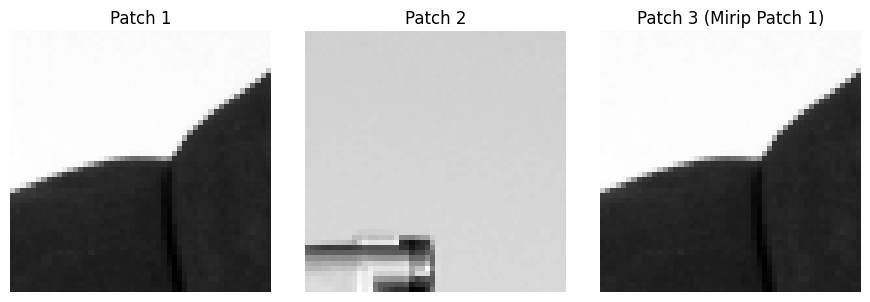

In [1]:
import numpy as np
from skimage import data, img_as_float
from scipy.spatial import distance
import matplotlib.pyplot as plt

# 1. Buat dua patch citra sederhana atau ambil dari citra asli
image = img_as_float(data.camera())
patch1 = image[100:150, 100:150]
patch2 = image[100:150, 300:350] # Patch dari lokasi berbeda
patch3 = patch1 + 0.1 # Patch1 dengan sedikit noise/perubahan intensitas
patch3 = np.clip(patch3, 0, 1) # Pastikan nilai tetap di [0, 1]

# 2. Flatten patch menjadi vektor 1D
vec1 = patch1.flatten()
vec2 = patch2.flatten()
vec3 = patch3.flatten()

# 3. Hitung Jarak Euclidean (L2)
dist_l2_12 = distance.euclidean(vec1, vec2)
dist_l2_13 = distance.euclidean(vec1, vec3)

# 4. Hitung Jarak Manhattan (L1 - disebut 'cityblock' di scipy)
dist_l1_12 = distance.cityblock(vec1, vec2)
dist_l1_13 = distance.cityblock(vec1, vec3)

# 5. Tampilkan hasil dan patch
print(f"Jarak Euclidean antara Patch 1 dan Patch 2: {dist_l2_12:.4f}")
print(f"Jarak Euclidean antara Patch 1 dan Patch 3: {dist_l2_13:.4f}")
print(f"Jarak Manhattan antara Patch 1 dan Patch 2: {dist_l1_12:.4f}")
print(f"Jarak Manhattan antara Patch 1 dan Patch 3: {dist_l1_13:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(9, 3))
axes[0].imshow(patch1, cmap='gray')
axes[0].set_title('Patch 1')
axes[0].axis('off')
axes[1].imshow(patch2, cmap='gray')
axes[1].set_title('Patch 2')
axes[1].axis('off')
axes[2].imshow(patch3, cmap='gray')
axes[2].set_title('Patch 3 (Mirip Patch 1)')
axes[2].axis('off')
plt.tight_layout()
plt.show()

Cosine Similarity antara Image 1 (Astronaut) dan Image 2 (Coffee): 0.8156
Cosine Similarity antara Image 1 (Astronaut) dan Image 3 (Astronaut): 1.0000
Cosine Similarity antara Image 1 (Astronaut) dan Image 4 (Astronaut Downsampled): 1.0000


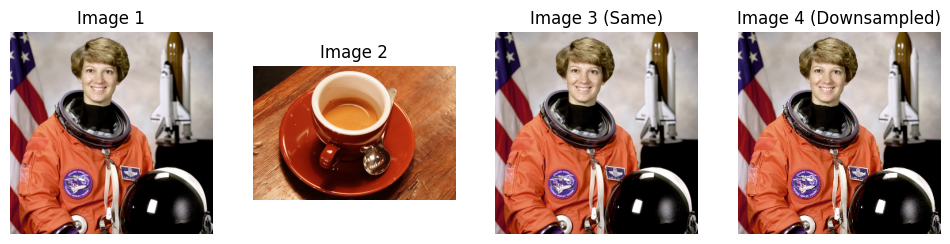

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, img_as_ubyte, io, color
from scipy.spatial import distance

# Fungsi untuk menghitung histogram RGB gabungan
def calculate_rgb_histogram(image, bins=16):
    img_uint8 = img_as_ubyte(image)
    hist_r, _ = np.histogram(img_uint8[:,:,0].ravel(), bins=bins, range=(0, 256))
    hist_g, _ = np.histogram(img_uint8[:,:,1].ravel(), bins=bins, range=(0, 256))
    hist_b, _ = np.histogram(img_uint8[:,:,2].ravel(), bins=bins, range=(0, 256))
    # Gabungkan histogram R, G, B menjadi satu vektor fitur
    hist_combined = np.concatenate((hist_r, hist_g, hist_b))
    # Normalisasi (opsional, tapi sering dilakukan)
    hist_combined = hist_combined.astype(float) / np.sum(hist_combined)
    return hist_combined

# 1. Muat dua citra berwarna
try:
    # Gunakan citra berbeda dari skimage atau file Anda
    image1 = data.astronaut()
    image2 = data.coffee() # Citra yang berbeda
    image3 = data.astronaut() # Citra yang sama (untuk perbandingan)
    image4 = image1[::2, ::2, :] # Versi downsampled dari image1
except Exception as e:
    print(f"Gagal memuat data skimage: {e}. Membuat citra dummy.")
    image1 = np.random.rand(100, 100, 3)
    image2 = np.random.rand(100, 100, 3) * 0.5
    image3 = image1.copy()
    image4 = image1[::2,::2,:]


# 2. Hitung histogram untuk setiap citra
hist1 = calculate_rgb_histogram(image1)
hist2 = calculate_rgb_histogram(image2)
hist3 = calculate_rgb_histogram(image3)
hist4 = calculate_rgb_histogram(image4)

# 3. Hitung Cosine Similarity (1 - Cosine Distance)
# scipy.spatial.distance.cosine menghitung jarak (1 - similarity)
sim_12 = 1 - distance.cosine(hist1, hist2)
sim_13 = 1 - distance.cosine(hist1, hist3)
sim_14 = 1 - distance.cosine(hist1, hist4)

# 4. Tampilkan hasil
print(f"Cosine Similarity antara Image 1 (Astronaut) dan Image 2 (Coffee): {sim_12:.4f}")
print(f"Cosine Similarity antara Image 1 (Astronaut) dan Image 3 (Astronaut): {sim_13:.4f}")
print(f"Cosine Similarity antara Image 1 (Astronaut) dan Image 4 (Astronaut Downsampled): {sim_14:.4f}")

# Visualisasi (opsional)
fig, axes = plt.subplots(1, 4, figsize=(12, 3))
axes[0].imshow(image1); axes[0].set_title('Image 1'); axes[0].axis('off')
axes[1].imshow(image2); axes[1].set_title('Image 2'); axes[1].axis('off')
axes[2].imshow(image3); axes[2].set_title('Image 3 (Same)'); axes[2].axis('off')
axes[3].imshow(image4); axes[3].set_title('Image 4 (Downsampled)'); axes[3].axis('off')
plt.show()

SSIM (Ref vs Same): 1.0000
SSIM (Ref vs Noisy): 0.2961
SSIM (Ref vs Contrast): 0.9651
SSIM (Ref vs Blurred): 0.8027


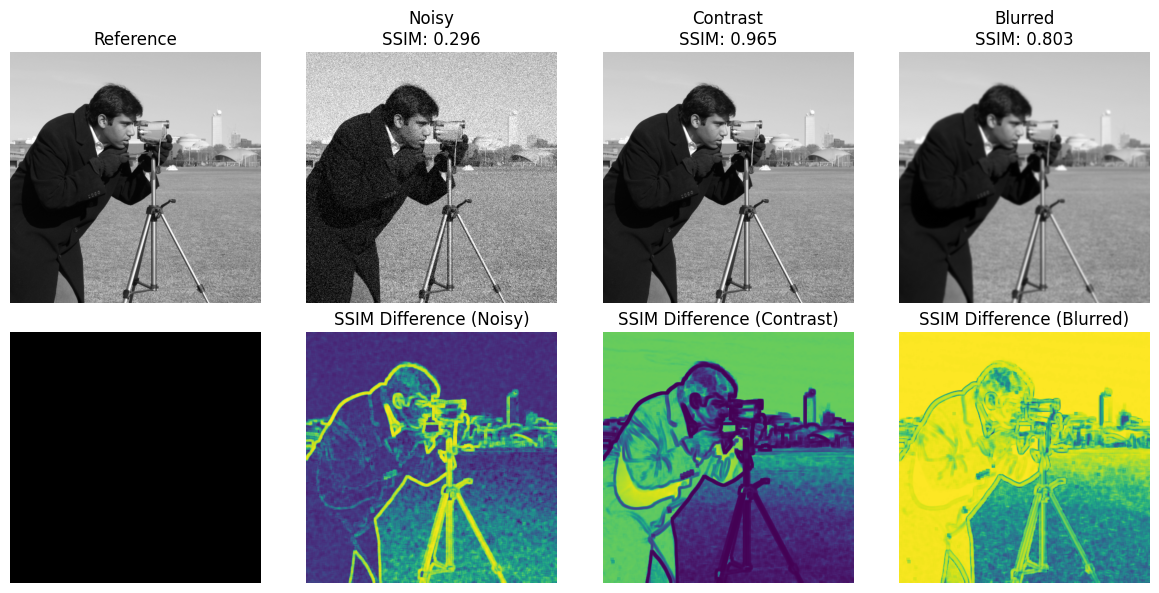

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, img_as_float
from skimage.metrics import structural_similarity as ssim
from skimage.transform import resize
from skimage.util import random_noise

# 1. Muat citra referensi
image_ref = img_as_float(data.camera())

# 2. Buat beberapa versi citra yang 'terdistorsi'
# a) Citra yang sama (SSIM harus 1)
image_same = image_ref.copy()
# b) Citra dengan noise Gaussian
image_noisy = random_noise(image_ref, mode='gaussian', var=0.01)
# c) Citra dengan kontras berbeda (contoh: dikalikan skalar)
image_contrast = np.clip(image_ref * 0.8, 0, 1)
# d) Citra yang di-blur
from skimage.filters import gaussian
image_blurred = gaussian(image_ref, sigma=1.5, channel_axis=None)  # channel_axis=None jika grayscale

# 3. Hitung SSIM antara citra referensi dan citra terdistorsi
# Pastikan dimensi citra sama jika diperlukan
# SSIM memerlukan data_range
data_range = image_ref.max() - image_ref.min()

ssim_same, _ = ssim(image_ref, image_same, data_range=data_range, full=True)
ssim_noisy, diff_noisy = ssim(image_ref, image_noisy, data_range=data_range, full=True)
ssim_contrast, diff_contrast = ssim(image_ref, image_contrast, data_range=data_range, full=True)
ssim_blurred, diff_blurred = ssim(image_ref, image_blurred, data_range=data_range, full=True)
# 'full=True' mengembalikan citra perbedaan SSIM juga

# 4. Tampilkan hasil SSIM dan citra perbedaan (jika menarik)
print(f"SSIM (Ref vs Same): {ssim_same:.4f}")
print(f"SSIM (Ref vs Noisy): {ssim_noisy:.4f}")
print(f"SSIM (Ref vs Contrast): {ssim_contrast:.4f}")
print(f"SSIM (Ref vs Blurred): {ssim_blurred:.4f}")

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
ax = axes.ravel()

ax[0].imshow(image_ref, cmap='gray'); ax[0].set_title('Reference'); ax[0].axis('off')
ax[1].imshow(image_noisy, cmap='gray'); ax[1].set_title(f'Noisy\nSSIM: {ssim_noisy:.3f}'); ax[1].axis('off')
ax[2].imshow(image_contrast, cmap='gray'); ax[2].set_title(f'Contrast\nSSIM: {ssim_contrast:.3f}'); ax[2].axis('off')
ax[3].imshow(image_blurred, cmap='gray'); ax[3].set_title(f'Blurred\nSSIM: {ssim_blurred:.3f}'); ax[3].axis('off')

# Menampilkan peta perbedaan SSIM
ax[4].imshow(np.zeros_like(image_ref), cmap='gray'); ax[4].set_title(''); ax[4].axis('off')  # Placeholder
ax[5].imshow(diff_noisy, cmap='viridis'); ax[5].set_title('SSIM Difference (Noisy)'); ax[5].axis('off')
ax[6].imshow(diff_contrast, cmap='viridis'); ax[6].set_title('SSIM Difference (Contrast)'); ax[6].axis('off')
ax[7].imshow(diff_blurred, cmap='viridis'); ax[7].set_title('SSIM Difference (Blurred)'); ax[7].axis('off')

plt.tight_layout()
plt.show()

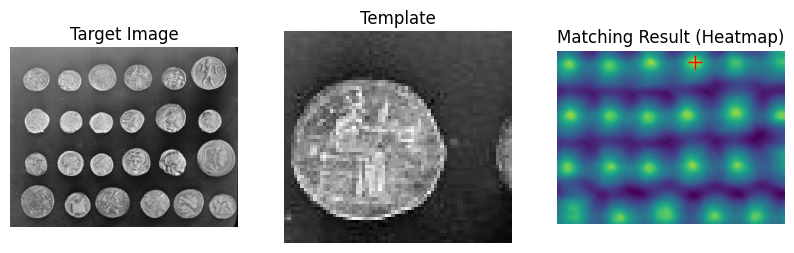

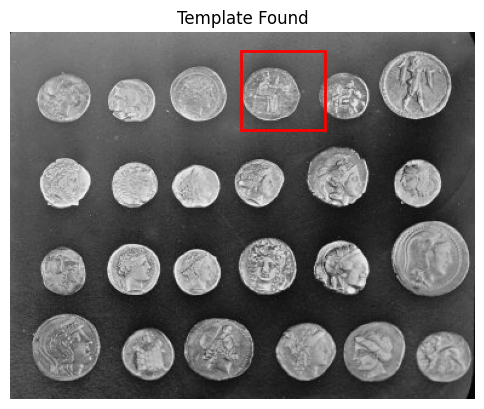

Template ditemukan di koordinat (x,y): (190, 15)


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
from skimage.feature import match_template

# 1. Muat citra target dan buat/muat citra template
image = data.coins()
# Ambil salah satu koin sebagai template (sesuaikan koordinat jika perlu)
template = image[15:80, 190:260]

# 2. Lakukan template matching menggunakan Normalized Cross-Correlation (metode default)
result = match_template(image, template)

# 3. Temukan lokasi dengan skor matching tertinggi
# np.argmax menemukan indeks linear, unravel_index mengubahnya ke koordinat 2D
ij = np.unravel_index(np.argmax(result), result.shape)
x, y = ij[::-1]  # Koordinat (x, y) dari sudut kiri atas template yang cocok

# 4. Visualisasi hasil
fig, ax = plt.subplots(1, 3, figsize=(10, 4))

ax[0].imshow(image, cmap='gray')
ax[0].set_title('Target Image')
ax[0].set_axis_off()

ax[1].imshow(template, cmap='gray')
ax[1].set_title('Template')
ax[1].set_axis_off()

# Menampilkan heatmap hasil matching (opsional)
ax[2].imshow(result, cmap='viridis')
ax[2].set_title('Matching Result (Heatmap)')
ax[2].set_axis_off()
# Tandai lokasi terbaik pada heatmap
ax[2].plot(x, y, 'r+', markersize=10)  # y, x karena ij adalah (row, col)

# Menampilkan kotak di lokasi terbaik pada citra asli (di plot terpisah agar lebih jelas)
fig2, ax_main = plt.subplots(figsize=(6, 6))
ax_main.imshow(image, cmap='gray')
ax_main.set_title('Template Found')
ax_main.set_axis_off()
h, w = template.shape
rect = plt.Rectangle((x, y), w, h, edgecolor='r', facecolor='none', lw=2)
ax_main.add_patch(rect)

plt.show()

print(f"Template ditemukan di koordinat (x,y): ({x}, {y})")

Memproses database citra...
- astronaut diproses.
- camera diproses.
- coffee diproses.
- coins diproses.
- chelsea diproses.

Hasil Retrieval (semakin ke kanan, semakin tidak mirip):
Rank 1: chelsea (Distance: 0.000)
Rank 2: coins (Distance: 0.288)
Rank 3: coffee (Distance: 0.359)
Rank 4: astronaut (Distance: 0.461)
Rank 5: camera (Distance: 0.602)


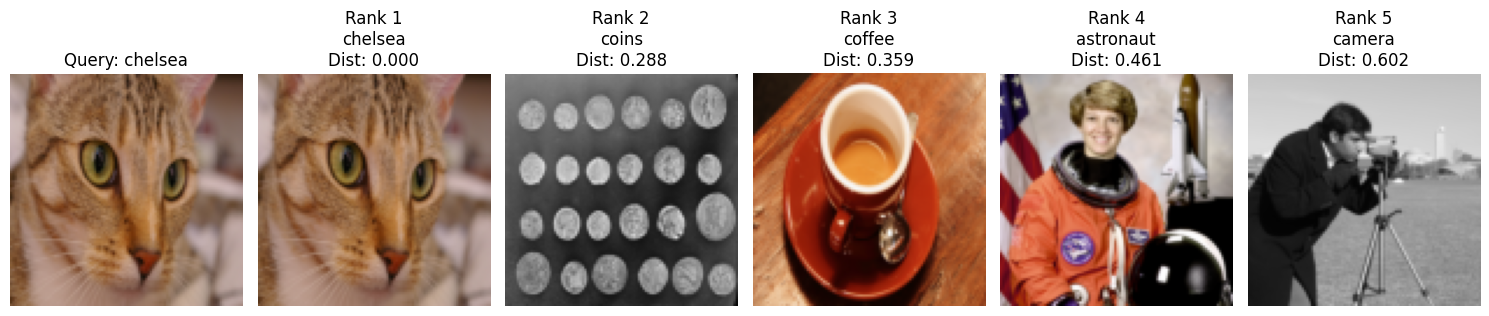

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, io, color, transform, img_as_float
from scipy.spatial import distance

def calculate_rgb_histogram(image, bins=16):
    if image.dtype == float:
        image = img_as_ubyte(image)
    hist_r, _ = np.histogram(image[:,:,0].ravel(), bins=bins, range=(0, 256))
    hist_g, _ = np.histogram(image[:,:,1].ravel(), bins=bins, range=(0, 256))
    hist_b, _ = np.histogram(image[:,:,2].ravel(), bins=bins, range=(0, 256))
    hist_combined = np.concatenate((hist_r, hist_g, hist_b))
    hist_sum = np.sum(hist_combined)
    if hist_sum > 0:
        hist_combined = hist_combined.astype(float) / hist_sum
    else:
        hist_combined = hist_combined.astype(float)
    return hist_combined

# 1. Prepare image database
image_db_names = ["astronaut", "camera", "coffee", "coins", "chelsea"]
database_images = []
database_hists = []

print("Memproses database citra...")
for name in image_db_names:
    try:
        img = getattr(data, name)()
        if img.ndim == 2:
            img = color.gray2rgb(img)
        img_resized = transform.resize(img, (100, 100), anti_aliasing=True)
        database_images.append(img_resized)
        database_hists.append(calculate_rgb_histogram(img_resized))
        print(f"- {name} diproses.")
    except Exception as e:
        print(f"Error memproses {name}: {e}")

# Select query image
query_image_name = "chelsea"
query_index = image_db_names.index(query_image_name)
query_image = database_images[query_index]
query_hist = database_hists[query_index]

# 2. Calculate distances
distances = []
for i, hist in enumerate(database_hists):
    dist = distance.cosine(query_hist, hist)
    distances.append(dist)

# 3. Sort results
sorted_indices = np.argsort(distances)

# 4. Display results
num_results_to_show = len(database_images)
fig, axes = plt.subplots(1, num_results_to_show + 1, figsize=(15, 3))

# Show query
axes[0].imshow(query_image)
axes[0].set_title(f"Query: {query_image_name}")
axes[0].axis('off')

# Show sorted results
print("\nHasil Retrieval (semakin ke kanan, semakin tidak mirip):")
for i, idx in enumerate(sorted_indices):
    img_rank = i + 1
    ax = axes[img_rank]
    ax.imshow(database_images[idx])
    ax.set_title(f"Rank {img_rank}\n{image_db_names[idx]}\nDist: {distances[idx]:.3f}")
    ax.axis('off')
    print(f"Rank {img_rank}: {image_db_names[idx]} (Distance: {distances[idx]:.3f})")

# Turn off unused axes
for j in range(num_results_to_show + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

## **PENUGASAN**

Processing image database...
- astronaut processed.
- camera processed.
- coffee processed.
- coins processed.
- chelsea processed.

Retrieval Results (left to right: most to least similar):
Rank 1: chelsea (Distance: 0.000)
Rank 2: astronaut (Distance: 0.050)
Rank 3: coffee (Distance: 0.176)
Rank 4: camera (Distance: 0.194)
Rank 5: coins (Distance: 0.211)


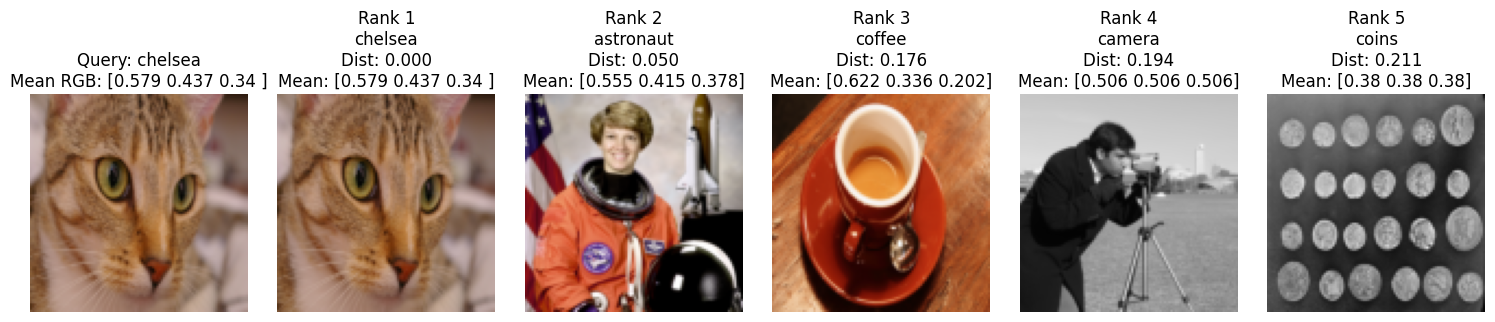

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, color, transform, img_as_float
from scipy.spatial import distance

# 1. Modified feature extraction: Mean RGB color (3D vector)
def calculate_mean_color(image):
    """Calculate mean R, G, B values as a 3D feature vector"""
    return np.mean(image, axis=(0,1))  # Returns [mean_R, mean_G, mean_B]

# Prepare image database
image_db_names = ["astronaut", "camera", "coffee", "coins", "chelsea"]
database_images = []
database_features = []  # Now stores mean RGB values instead of histograms

print("Processing image database...")
for name in image_db_names:
    try:
        img = getattr(data, name)()
        if img.ndim == 2:
            img = color.gray2rgb(img)
        img_resized = transform.resize(img, (100, 100), anti_aliasing=True)
        database_images.append(img_resized)
        database_features.append(calculate_mean_color(img_resized))
        print(f"- {name} processed.")
    except Exception as e:
        print(f"Error processing {name}: {e}")

# Select query image ("chelsea" the cat by default)
query_image_name = "chelsea"
query_index = image_db_names.index(query_image_name)
query_image = database_images[query_index]
query_feature = database_features[query_index]

# 2. Calculate Euclidean distances between query and database images
distances = []
for feature in database_features:
    dist = distance.euclidean(query_feature, feature)
    distances.append(dist)

# 3. Sort results by similarity (ascending order)
sorted_indices = np.argsort(distances)

# 4. Display results
num_results = len(database_images)
fig, axes = plt.subplots(1, num_results + 1, figsize=(15, 3))

# Show query image
axes[0].imshow(query_image)
axes[0].set_title(f"Query: {query_image_name}\nMean RGB: {query_feature.round(3)}")
axes[0].axis('off')

# Show ranked results
print("\nRetrieval Results (left to right: most to least similar):")
for rank, idx in enumerate(sorted_indices, start=1):
    ax = axes[rank]
    ax.imshow(database_images[idx])
    ax.set_title(f"Rank {rank}\n{image_db_names[idx]}\nDist: {distances[idx]:.3f}\nMean: {database_features[idx].round(3)}")
    ax.axis('off')
    print(f"Rank {rank}: {image_db_names[idx]} (Distance: {distances[idx]:.3f})")

# Hide unused axes
for j in range(num_results + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

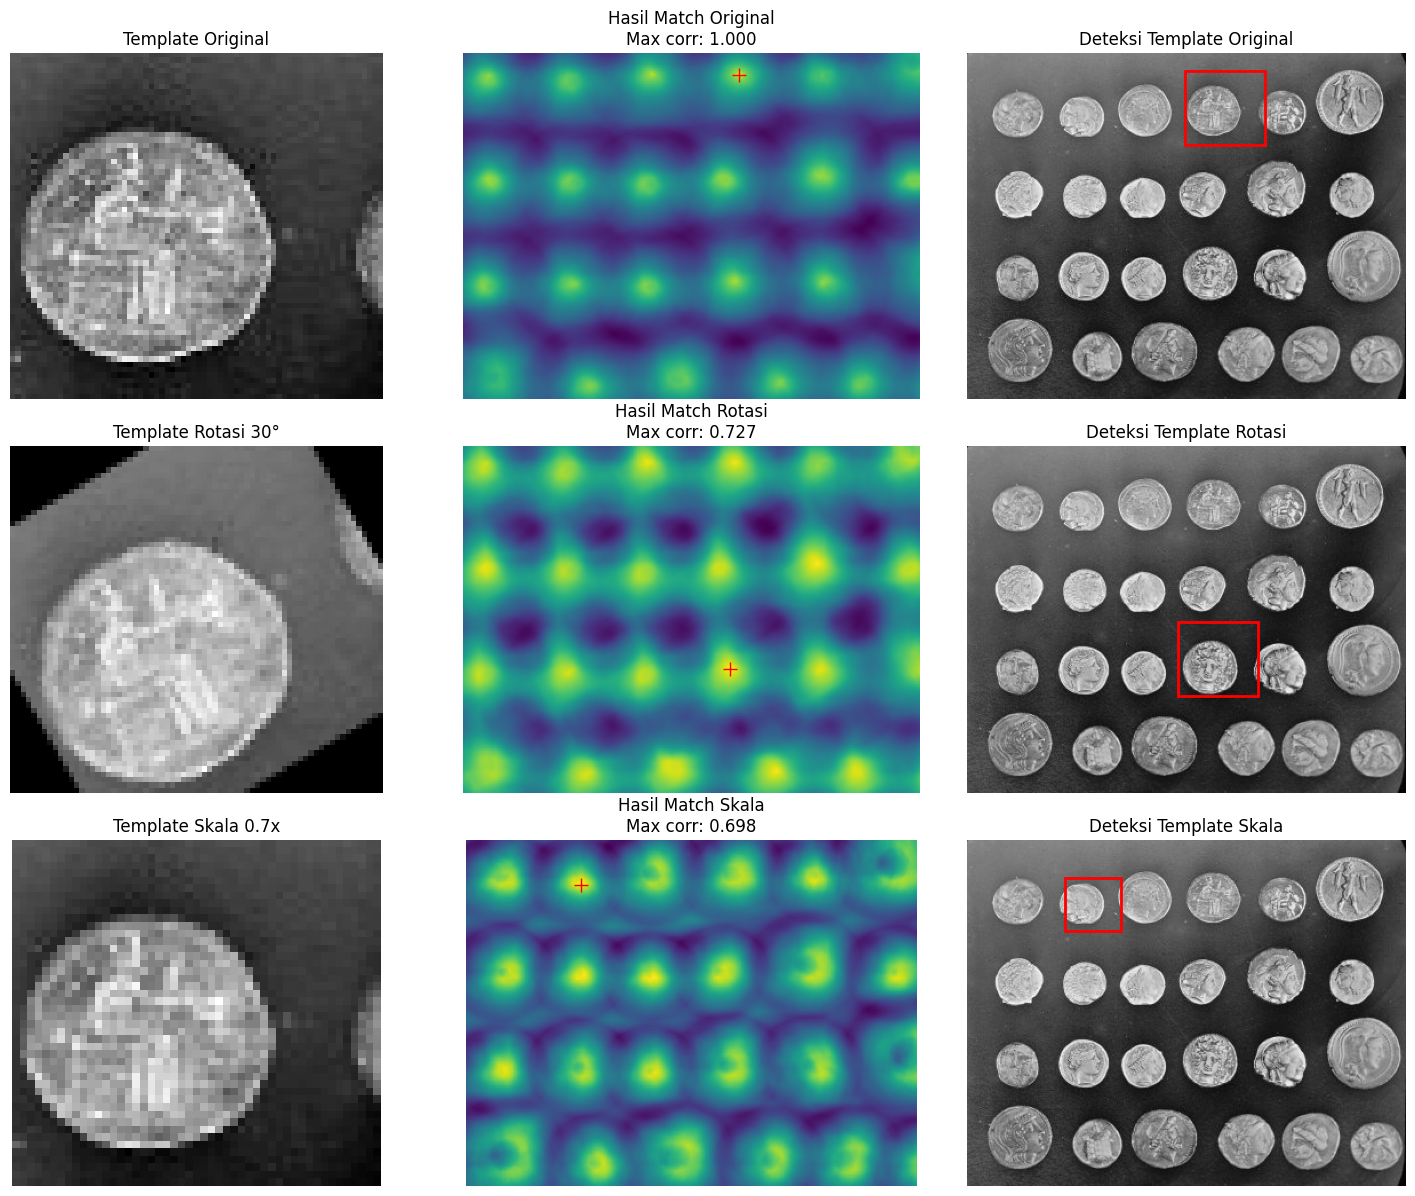

Template Original - Korelasi maksimum: 1.000 pada koordinat (190, 15)
Template Rotasi  - Korelasi maksimum: 0.727 pada koordinat (184, 153)
Template Skala   - Korelasi maksimum: 0.698 pada koordinat (85, 33)


In [10]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, transform
from skimage.feature import match_template

# 1. Muat citra target
image = data.coins()

# 2. Ambil salah satu koin sebagai template dasar
template_original = image[15:80, 190:260]

# 3. Buat versi template yang dirotasi dan diubah skala
template_rotated = transform.rotate(template_original, angle=30)
template_scaled = transform.rescale(template_original, scale=0.7,
                                    anti_aliasing=True)

# 4. Lakukan template matching untuk ketiga template
result_original = match_template(image, template_original)
result_rotated = match_template(image, template_rotated)
result_scaled = match_template(image, template_scaled)

# 5. Temukan lokasi dengan skor matching tertinggi untuk setiap hasil
ij_original = np.unravel_index(np.argmax(result_original), result_original.shape)
ij_rotated = np.unravel_index(np.argmax(result_rotated), result_rotated.shape)
ij_scaled = np.unravel_index(np.argmax(result_scaled), result_scaled.shape)

# Konversi ke koordinat (x, y)
x_original, y_original = ij_original[::-1]
x_rotated, y_rotated = ij_rotated[::-1]
x_scaled, y_scaled = ij_scaled[::-1]

# 6. Dapatkan nilai maksimum korelasi untuk setiap template
max_corr_original = np.max(result_original)
max_corr_rotated = np.max(result_rotated)
max_corr_scaled = np.max(result_scaled)

# 7. Visualisasi hasil
fig, axes = plt.subplots(3, 3, figsize=(15, 12))

# Baris 1: Template original
axes[0, 0].imshow(template_original, cmap='gray')
axes[0, 0].set_title('Template Original')
axes[0, 0].set_axis_off()

axes[0, 1].imshow(result_original, cmap='viridis')
axes[0, 1].set_title(f'Hasil Match Original\nMax corr: {max_corr_original:.3f}')
axes[0, 1].set_axis_off()
axes[0, 1].plot(x_original, y_original, 'r+', markersize=10)

axes[0, 2].imshow(image, cmap='gray')
axes[0, 2].set_title('Deteksi Template Original')
axes[0, 2].set_axis_off()
h, w = template_original.shape
rect = plt.Rectangle((x_original, y_original), w, h, edgecolor='r', facecolor='none', lw=2)
axes[0, 2].add_patch(rect)

# Baris 2: Template yang dirotasi
axes[1, 0].imshow(template_rotated, cmap='gray')
axes[1, 0].set_title('Template Rotasi 30°')
axes[1, 0].set_axis_off()

axes[1, 1].imshow(result_rotated, cmap='viridis')
axes[1, 1].set_title(f'Hasil Match Rotasi\nMax corr: {max_corr_rotated:.3f}')
axes[1, 1].set_axis_off()
axes[1, 1].plot(x_rotated, y_rotated, 'r+', markersize=10)

axes[1, 2].imshow(image, cmap='gray')
axes[1, 2].set_title('Deteksi Template Rotasi')
axes[1, 2].set_axis_off()
h_rot, w_rot = template_rotated.shape
rect_rot = plt.Rectangle((x_rotated, y_rotated), w_rot, h_rot, edgecolor='r', facecolor='none', lw=2)
axes[1, 2].add_patch(rect_rot)

# Baris 3: Template yang diubah skala
axes[2, 0].imshow(template_scaled, cmap='gray')
axes[2, 0].set_title('Template Skala 0.7x')
axes[2, 0].set_axis_off()

axes[2, 1].imshow(result_scaled, cmap='viridis')
axes[2, 1].set_title(f'Hasil Match Skala\nMax corr: {max_corr_scaled:.3f}')
axes[2, 1].set_axis_off()
axes[2, 1].plot(x_scaled, y_scaled, 'r+', markersize=10)

axes[2, 2].imshow(image, cmap='gray')
axes[2, 2].set_title('Deteksi Template Skala')
axes[2, 2].set_axis_off()
h_scale, w_scale = template_scaled.shape
rect_scale = plt.Rectangle((x_scaled, y_scaled), w_scale, h_scale, edgecolor='r', facecolor='none', lw=2)
axes[2, 2].add_patch(rect_scale)

plt.tight_layout()
plt.show()

print(f"Template Original - Korelasi maksimum: {max_corr_original:.3f} pada koordinat ({x_original}, {y_original})")
print(f"Template Rotasi  - Korelasi maksimum: {max_corr_rotated:.3f} pada koordinat ({x_rotated}, {y_rotated})")
print(f"Template Skala   - Korelasi maksimum: {max_corr_scaled:.3f} pada koordinat ({x_scaled}, {y_scaled})")